Install and import necessary libraries

In [41]:
#!pip install pandas
#!pip install matplotlin
#!pip install seaborn
#!pip install termcolor
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from termcolor import colored
from scipy import stats
import copy

1. Data Collection & Initial Assessment <br>
To verify data integrity, understand structure, and check for issues before analysis.

In [37]:
file_path = r'C:\Users\bijin\OneDrive\Documents\PROJECTS\credit card customer churn\BankChurners.csv'

#load the dataset
df = pd.read_csv(file_path)

#Display basic information about the dataset
df_info = df.info()
df_shape = df.shape
df_head = df.head()

df_info, df_shape, df_head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

(None,
 (10127, 21),
    CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
 0  768805383  Existing Customer            45      M                3   
 1  818770008  Existing Customer            49      F                5   
 2  713982108  Existing Customer            51      M                3   
 3  769911858  Existing Customer            40      F                4   
 4  709106358  Existing Customer            40      M                3   
 
   Education_Level Marital_Status Income_Category Card_Category  \
 0     High School        Married     $60K - $80K          Blue   
 1        Graduate         Single  Less than $40K          Blue   
 2        Graduate        Married    $80K - $120K          Blue   
 3     High School        Unknown  Less than $40K          Blue   
 4      Uneducated        Married     $60K - $80K          Blue   
 
    Months_on_book  ...  Months_Inactive_12_mon  Contacts_Count_12_mon  \
 0              39  ...                       1        

Overview of the dataset: <br>
-> Total records: 10,127 <br>
-> Toal COlumns: 21 <br>
-> Data Types: <br>
Numerical(15): Includes Integer(int64) and floating point(float64) values. <br>
Categorical(6): INcludes strings(object)

Observations:
1. The CLIENTNUM column is a unique identifier, so it does not contribute to analysis. <br>
2. The Attrition_Flag column indicates customer churn (whether they have left the service). <br>
3. Key financial attributes include Credit Limit, Total Revolving Balance, Avg Utilization Ratio, and Total Transaction Amount.

2. Data Quality Assessment <br>
To evaluate reliability and usability before analysis.

In [38]:
# Data types check
print("\nData types:")
print(df.dtypes)

# Checking for missing values
print("\nMissing values count:")
print(df.isnull().sum())
print(f"\nPercentage of missing values: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# Checking for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Basic statistics
print("\nBasic statistics for numerical columns:")
print(df.describe())

# Distribution of categorical variables
print("\nDistribution of categorical variables:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())
    print(f"{col} unique values: {df[col].nunique()}")


Data types:
CLIENTNUM                     int64
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

Missing values count:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status

2.1 Completeness Assessment: <br>
-> No missing values detected in any column (all columns have 10,127 non-null values).<br>

2.2 Validity & Accuracy: <br>
-> No invalid or inaccurate data detected in any column (all columns have 10,127 non-null).<br>
-> Data types appear appropriate.<br>
-> No duplicate rows detected (all rows are unique).<br>
-> There are some "Unknown' values in categorical fields like Education_Level, Marital_Status, Income_Category. <br> 
-> I am keeping "Unknown" 

2.3 Uniqueness: <br>
-> CLIENTNUM appears to be a unique identifier in the sample data.

2.4 Timeliness: <br>
-> The data doesn't show specific timestamps, but Months_on_book indicates the duration of customer relationships, which ranges from 21 to 56 months in the sample.

2.5 Distribution Analysis

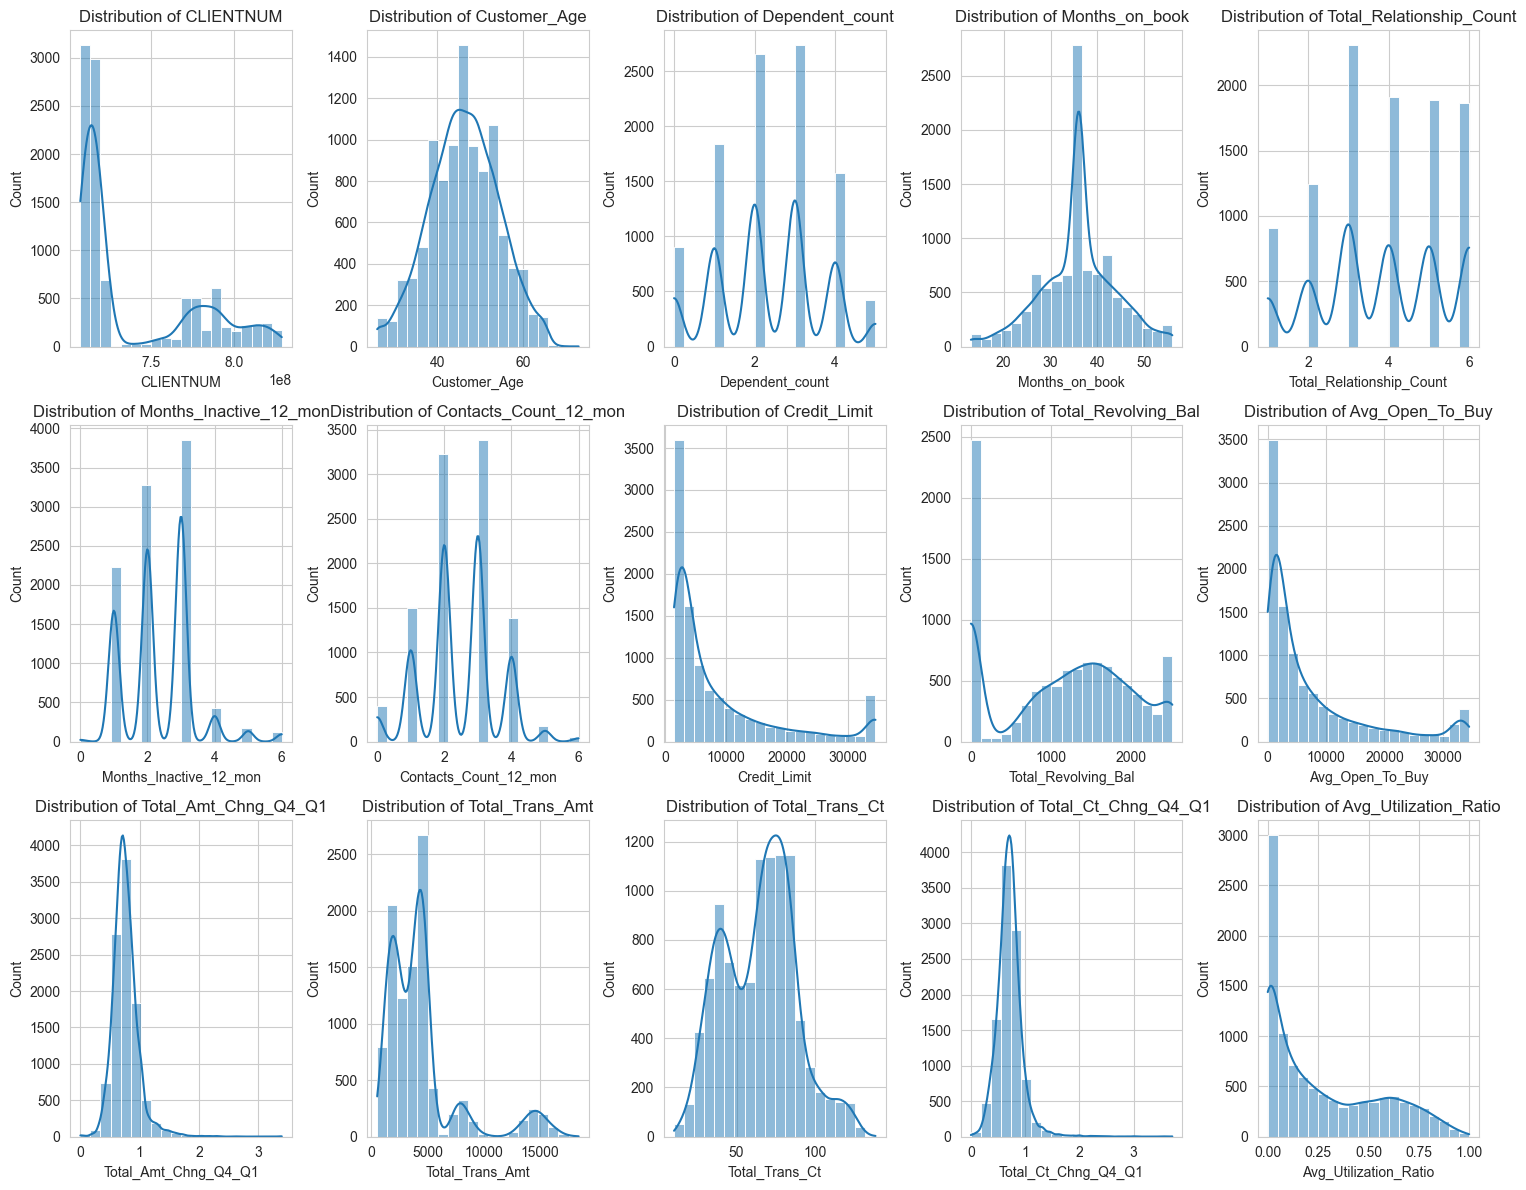

In [39]:

numeric_columns = df.select_dtypes(include=['int64','float64']).columns

def plot_numeric_dist():
    
    global numeric_columns
    #create subplots dynamically based on the number of columns
    num_cols = 5  # Fixed at 3 columns
    num_rows = (len(numeric_columns) + num_cols - 1) // num_cols 

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 4 * num_rows))
    axes = axes.flatten()  # Flatten axes array for easy iteration

    #loop through each numeric column and plot a histogram
    for i, col in enumerate(numeric_columns):
        sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
        #sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

    # Hide any empty subplots if the number of columns is not a multiple of 3
    for i in range(len(numeric_columns), len(axes)):
        fig.delaxes(axes[i])

    #Adjust layout
    plt.tight_layout()
    plt.show()

plot_numeric_dist()

-> Customer_Age appears to be normally distributed (adults of various ages) <br>
-> Credit_Limit shows a wide range, likely right-skewed <br>
-> Total_Trans_Amt and Total_Trans_Ct also likely have right-skewed distributions <br>

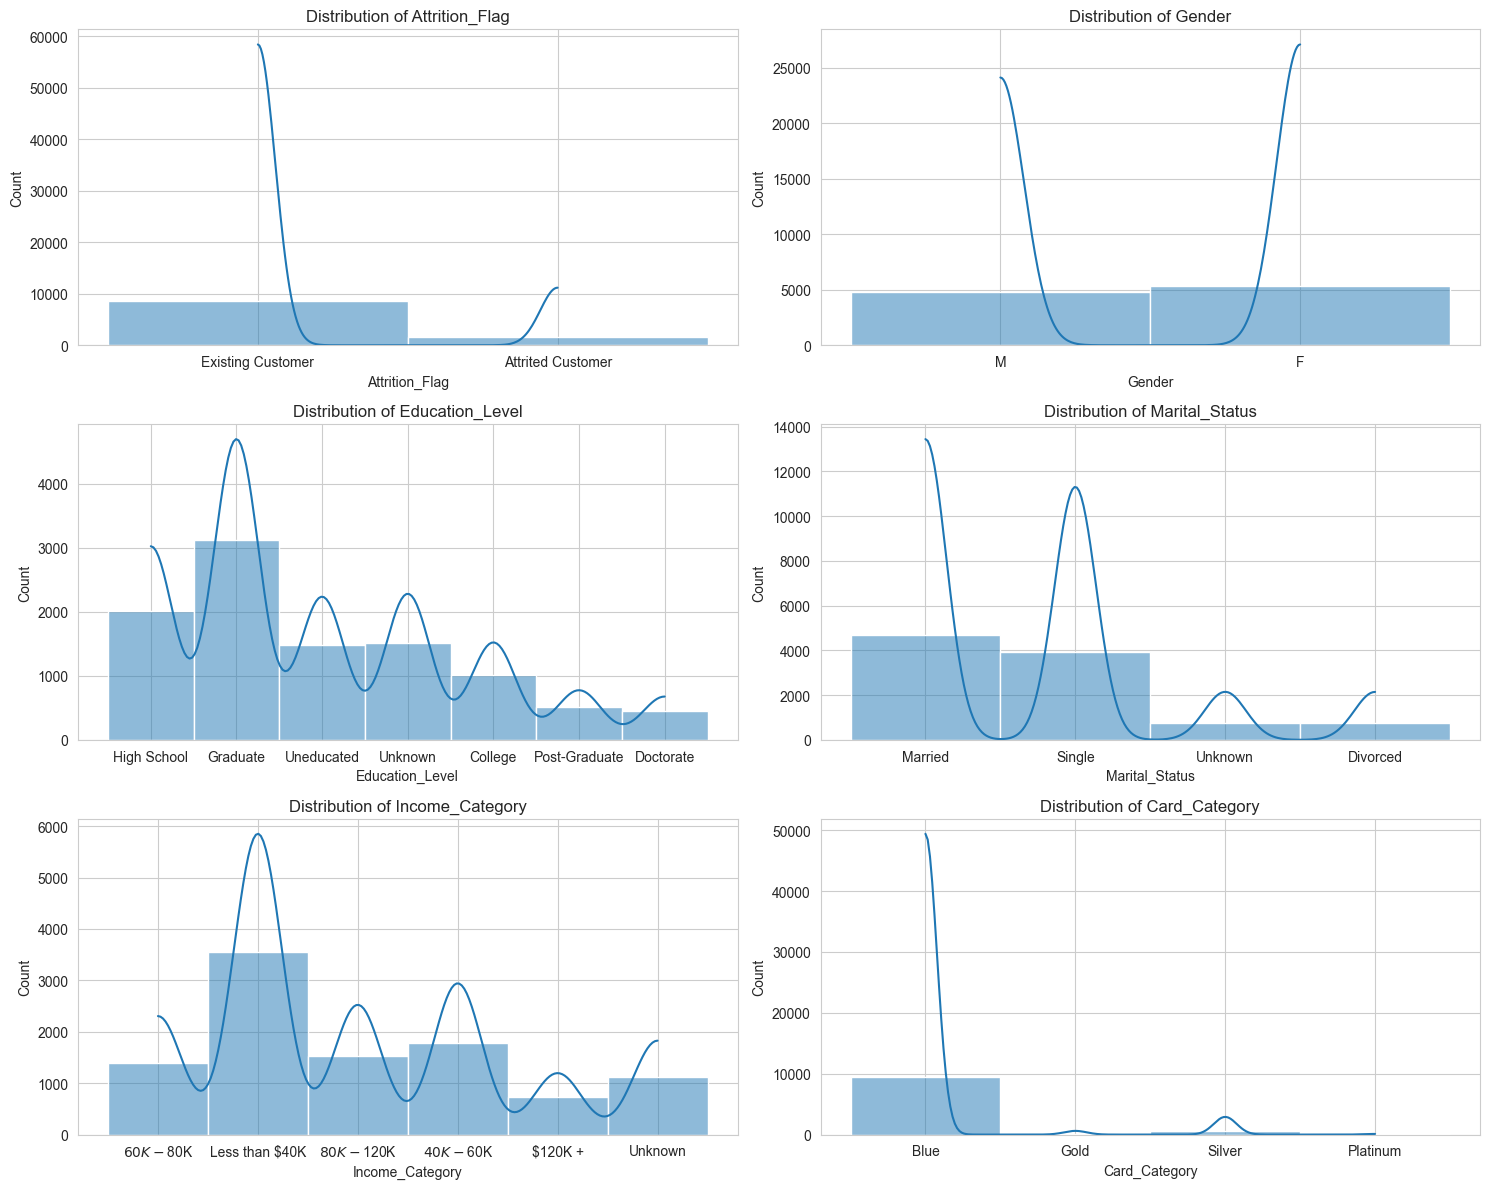

In [40]:
#distribution of categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

def category_distribution():
    
    global categorical_columns
    #create subplots dynamically based on the number of columns
    num_cols = 2 # Fixed at 3 columns
    num_rows = (len(categorical_columns) + num_cols - 1) // num_cols 

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 4 * num_rows))
    axes = axes.flatten()  # Flatten axes array for easy iteration

    #loop through each numeric column and plot a histogram
    for i, col in enumerate(categorical_columns):
        sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
        #sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

    # Hide any empty subplots if the number of columns is not a multiple of 3
    for i in range(len(categorical_columns), len(axes)):
        fig.delaxes(axes[i])

    #Adjust layout
    plt.tight_layout()
    plt.show()
category_distribution()

2.6 Outlier Detection

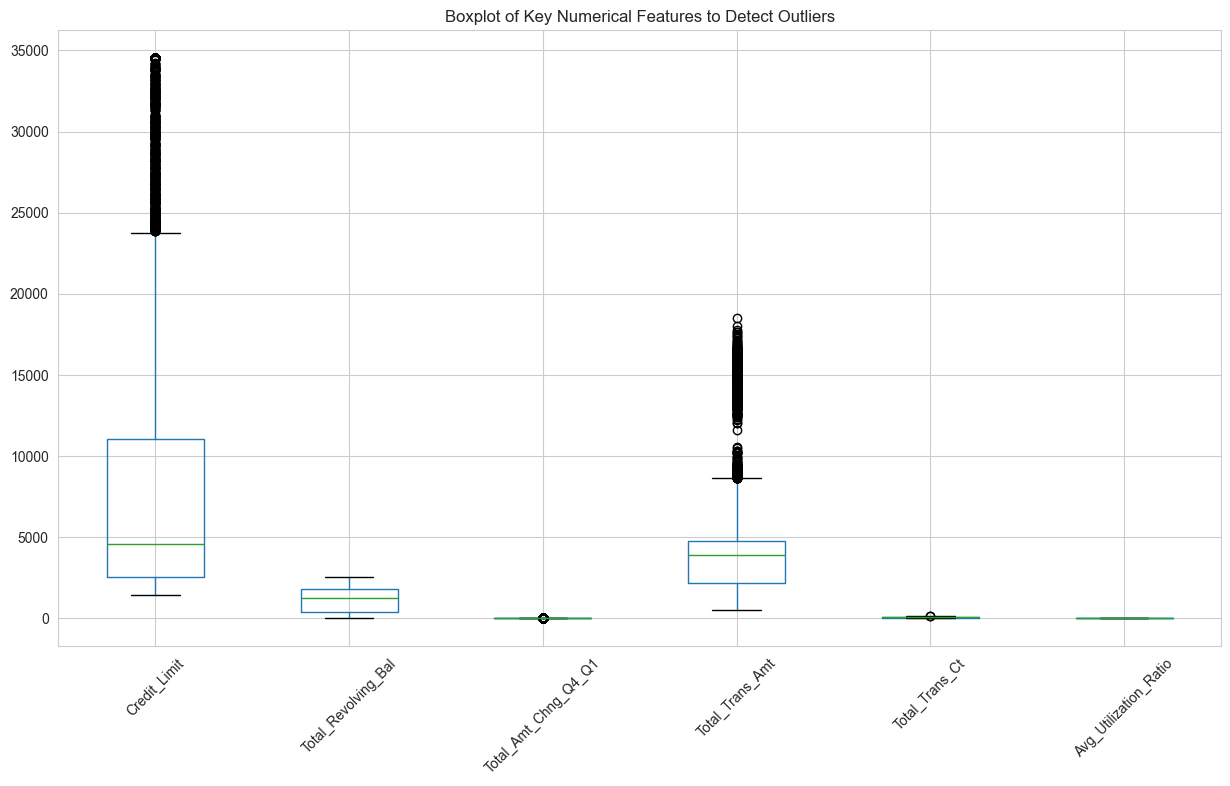

In [41]:
# Set style for plots
sns.set_style("whitegrid")

# Plot boxplots for numerical columns to visualize outliers
numerical_cols = ['Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 
                  'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

plt.figure(figsize=(15, 8))
df[numerical_cols].boxplot(rot=45)
plt.title("Boxplot of Key Numerical Features to Detect Outliers")
plt.show()


-> Outliers can distort analysis and affect model performance.

Observations from Boxplot: <br>
-> Credit Limit: A few extreme values near $34,500.<br>
-> Total Revolving Balance: Appears mostly within a reasonable range.<br>
-> Total Transaction Amount & Count: Contains high-value outliers.<br>
-> Total Amount Change (Q4 to Q1): Outliers above 3.39.<br>
-> Utilization Ratio: Values close to 1 indicate customers fully using their credit limit.<br>

In [42]:
# now let's find out total number of outliers in each numerical column
# indentifying potential outliers using IQR method
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
print("\nTotal number of outliers in each numerical column:")
print(outliers)



Total number of outliers in each numerical column:
Credit_Limit             984
Total_Revolving_Bal        0
Total_Amt_Chng_Q4_Q1     396
Total_Trans_Amt          896
Total_Trans_Ct             2
Avg_Utilization_Ratio      0
dtype: int64


Outlier Count per Column: <br>
-> Credit Limit: 984 outliers (high-end values) <br>
-> Total Revolving Balance: No significant outliers <br>
-> Total Transaction Amount: 896 outliers (likely high-spending customers) <br>
-> Total Transaction Count: Only 2 outliers <br>
-> Total Amount Change (Q4 to Q1): 396 outliers (sudden spending spikes) <br>
-> Utilization Ratio: No significant outliers <br>

3. Data Cleaning

3.1 dealing with missing values: <br>

-> There are no missing values in our dataset but "Unknown" values in category fields education_level, income_category and marital_status. <br>
-> Both Education_Level and INcome_category appear to have Bimodal Distribution. So, replacing Unknown values with "mode" central tendency is appropriate. As it is categorical attributes i am using mode. <br>
-> Marital Status: Keep "Unknown" as a separate category since it may hold significance.

In [43]:
df_cleaned = df.copy()  # Copy original dataframe

# Corrected mode imputation
df_cleaned['Education_Level'].replace('Unknown', df_cleaned['Education_Level'].mode()[0], inplace=True)
df_cleaned['Income_Category'].replace('Unknown', df_cleaned['Income_Category'].mode()[0], inplace=True)

# Validate replacements
unknown_counts = {
    "Education_Level": df_cleaned['Education_Level'].value_counts(),
    "Income_Category": df_cleaned['Income_Category'].value_counts(),
    "Marital_Status": df_cleaned['Marital_Status'].value_counts()
}

unknown_counts


{'Education_Level': Graduate         4647
 High School      2013
 Uneducated       1487
 College          1013
 Post-Graduate     516
 Doctorate         451
 Name: Education_Level, dtype: int64,
 'Income_Category': Less than $40K    4673
 $40K - $60K       1790
 $80K - $120K      1535
 $60K - $80K       1402
 $120K +            727
 Name: Income_Category, dtype: int64,
 'Marital_Status': Married     4687
 Single      3943
 Unknown      749
 Divorced     748
 Name: Marital_Status, dtype: int64}

3.2 Handling Outliers

In [44]:

# Manually apply Winsorization by capping values at the 1st and 99th percentile
for col in ["Credit_Limit", "Total_Trans_Amt"]:
    lower_percentile = df_cleaned[col].quantile(0.01)
    upper_percentile = df_cleaned[col].quantile(0.99)
    df_cleaned[col] = np.clip(df_cleaned[col], lower_percentile, upper_percentile)

# Apply log transformation for Total_Amt_Chng_Q4_Q1
df_cleaned["Total_Amt_Chng_Q4_Q1"] = np.log1p(df_cleaned["Total_Amt_Chng_Q4_Q1"])

# Verify the effect of outlier treatment
df_cleaned[numerical_cols].describe()


,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,8631.953698,1162.814061,0.558139,4399.222597,64.858695,0.274894
std,9088.776650,814.987335,0.117775,3374.329787,23.472570,0.275691
min,1438.300000,0.000000,0.000000,869.260000,10.000000,0.000000
25%,2555.000000,359.000000,0.489193,2155.500000,45.000000,0.023000
50%,4549.000000,1276.000000,0.551584,3899.000000,67.000000,0.176000
75%,11067.500000,1784.000000,0.620039,4741.000000,81.000000,0.503000
max,34516.000000,2517.000000,1.480922,15882.360000,139.000000,0.999000


Business Problem Recap: <br>

Harbor Trust Bank is experiencing a decline in credit card users. Since credit cards are a major revenue source (fees, interest, etc.), the bank wants to:<br>
✅ Identify factors influencing customer churn<br>
✅ Predict which customers are likely to leave<br>
✅ Develop strategies to improve retention<br>

The key challenge is to analyze which customers are leaving and why so that targeted strategies can be implemented.

EDA Strategy & Key Business Questions: <br>
-> EDA will help us explore customer behavior and spending patterns to uncover insights about churn.

1. CHurn Distribution Analysis.<br>
-> To understand how many customers churned vs. retained and if churn is a significant issue.

Churn Percentage:
 Existing Customer    83.934038
Attrited Customer    16.065962
Name: Attrition_Flag, dtype: float64


C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\2665298672.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x="Attrition_Flag", palette="Set2")


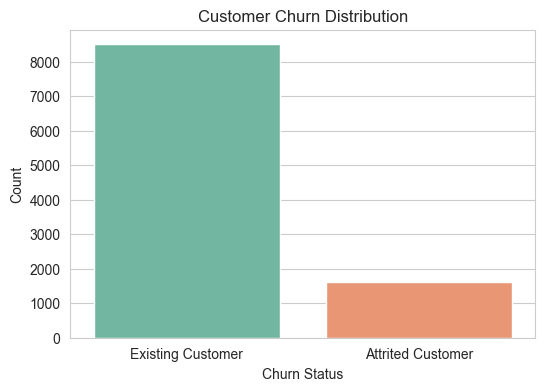

In [45]:
# Churn distribution
churn_counts = df_cleaned['Attrition_Flag'].value_counts()

# Churn percentage
churn_percentage = (churn_counts / df_cleaned.shape[0]) * 100
print("Churn Percentage:\n", churn_percentage)

# Visualizing churn rate
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x="Attrition_Flag", palette="Set2")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()


Business Insights: <br>
-> Customer Retention Focus: churn is low(~16%), retention strategies should focus on preventing future churn rather than immediate crisis intervention.

2.Customer Demographics & Churn <br>
-> To analyze age, gender, and marital status and see if specific groups churn more.

2a. Customer Age vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\2921149156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Customer_Age", palette="coolwarm")


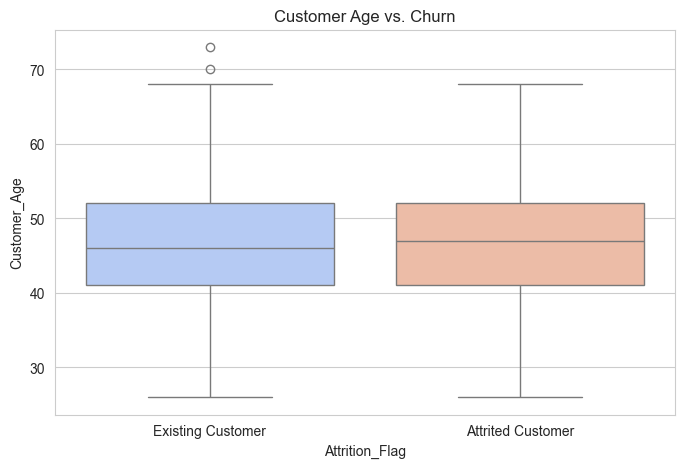

In [46]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Customer_Age", palette="coolwarm")
plt.title("Customer Age vs. Churn")
plt.show()

## **Customer Demographics & Churn Analysis**

### **📊 Key Observations:**
1. **Median Age Similarity:**  
   - The median age of **churned and retained customers appears similar** (~45-50 years).  
   - This suggests that **age alone may not be a strong factor in churn.**  

2. **Age Distribution Spread:**  
   - Both groups have customers ranging from **~30 to ~70 years**.  
   - A few **outliers (above 70 years)** exist, indicating some older customers with unusual behaviors.  

3. **Slightly Higher Age in Churned Customers:**  
   - The **churned group** has a slightly higher median age than existing customers.  
   - Older customers might be **switching banks due to better benefits elsewhere** or **reduced banking needs.**  

---

### **📌 Business Recommendations:**
✔️ **For Younger Customers:**  
   - Offer **more digital-friendly services** (mobile banking, app discounts).  
   - Provide **personalized credit-building options** to retain them.  

✔️ **For Older Customers:**  
   - Introduce **senior citizen banking benefits** (lower fees, priority service).  
   - Strengthen **customer service & relationship management** to prevent churn.  

---

This analysis helps in **targeted customer retention strategies** based on age demographics. 🚀

2b. Gender vs. Churn

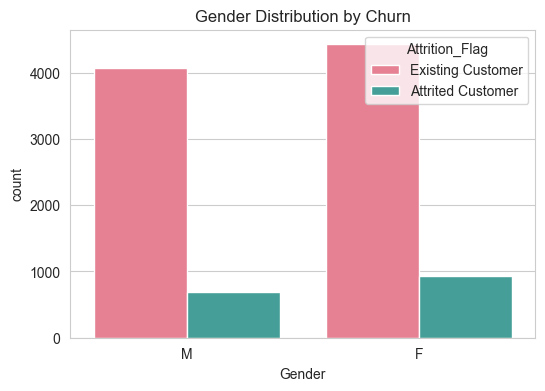

In [47]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x="Gender", hue="Attrition_Flag", palette="husl")
plt.title("Gender Distribution by Churn")
plt.show()



# Gender vs. Churn Analysis  

## 📊 Key Observations:  
- Female customers have a slightly higher representation in the dataset compared to male customers.  
- The churn rate appears to be somewhat similar across both genders, with a slightly higher churn observed among female customers.  
- While gender does not seem to be a strong factor in predicting churn, any noticeable difference could indicate variations in engagement, product preferences, or service satisfaction.  

## 📌 Business Recommendations:  
- Personalize marketing and engagement strategies based on gender preferences, such as tailored offers or communication styles.  
- Enhance customer experience programs to improve retention, especially for segments showing higher churn.  


2c. Marital Status vs. churn


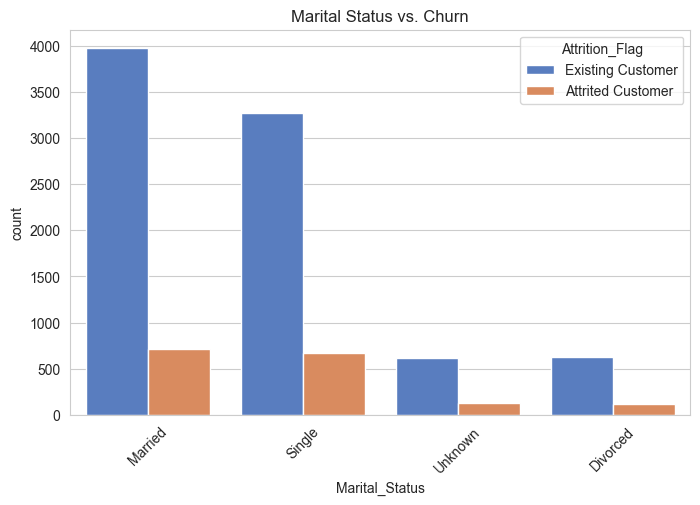

In [48]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x="Marital_Status", hue="Attrition_Flag", palette="muted")
plt.title("Marital Status vs. Churn")
plt.xticks(rotation=45)
plt.show()

# Marital Status vs. Churn Analysis  

## 📊 Key Observations:  
- Married and single customers form the majority of the customer base.  
- Churn is observed across all marital statuses, with single and married customers having the highest attrition.  
- The proportion of churn among divorced and unknown marital status customers is relatively lower, but their overall representation is also smaller.  

## 📌 Business Recommendations:  
- Investigate whether single customers face specific challenges or lack engagement that leads to higher churn.  
- Design targeted retention programs, such as loyalty benefits or personalized financial products, to improve customer stickiness.  
- Conduct surveys or customer feedback analysis to understand differences in financial behavior across marital statuses.  


3. Credit Behavior & Churn: <br>
-> To see if credit limit and utilization ratio affect churn.

3a. Credit LImit vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\3326184300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Credit_Limit", palette="coolwarm")


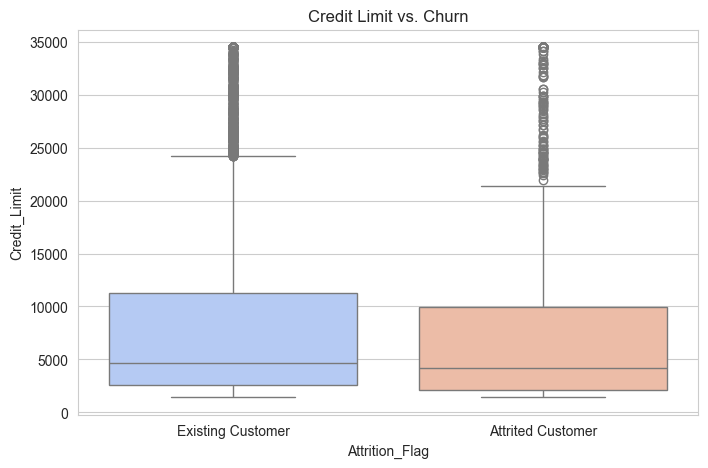

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Credit_Limit", palette="coolwarm")
plt.title("Credit Limit vs. Churn")
plt.show()


3b. Credit Utilization Ratio vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\1813165808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Avg_Utilization_Ratio", palette="coolwarm")


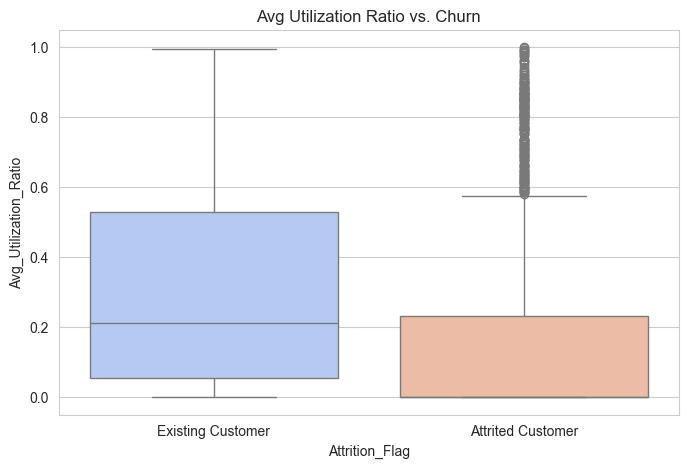

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Avg_Utilization_Ratio", palette="coolwarm")
plt.title("Avg Utilization Ratio vs. Churn")
plt.show()


4. Transaction Patterns & Churn: <br>
-> to analyze whether spending patterns impact churn.

4a.  Total Transaction Amount vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\1356620677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Amt", palette="coolwarm")


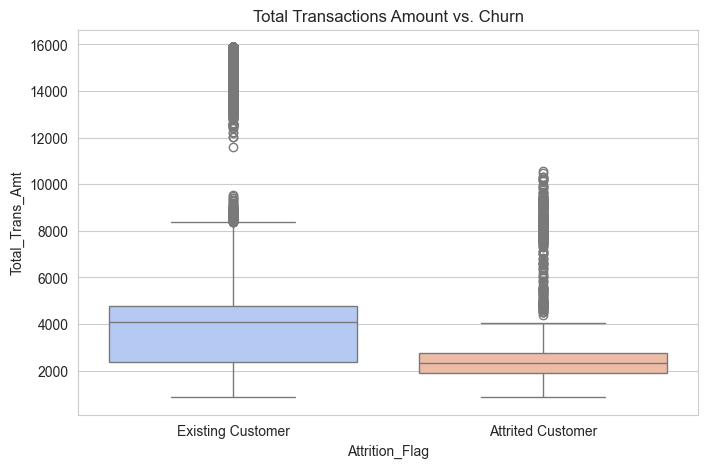

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Amt", palette="coolwarm")
plt.title("Total Transactions Amount vs. Churn")
plt.show()


4b. Total Transactions Count vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\1356620677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Amt", palette="coolwarm")


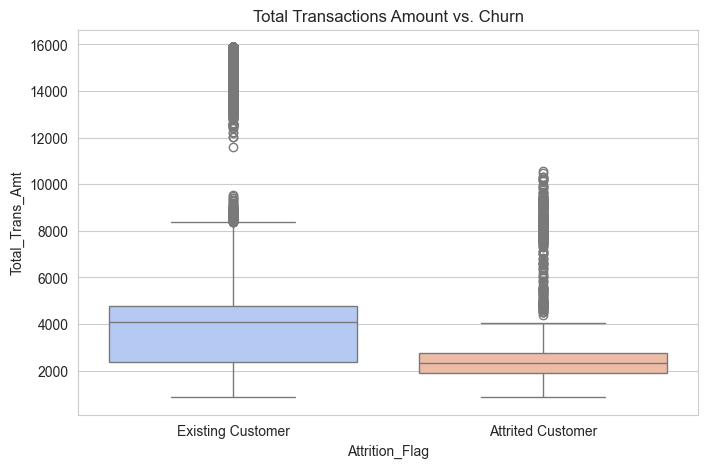

In [52]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Amt", palette="coolwarm")
plt.title("Total Transactions Amount vs. Churn")
plt.show()


4c. Total Transactions Count vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\903639843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Ct", palette="coolwarm")


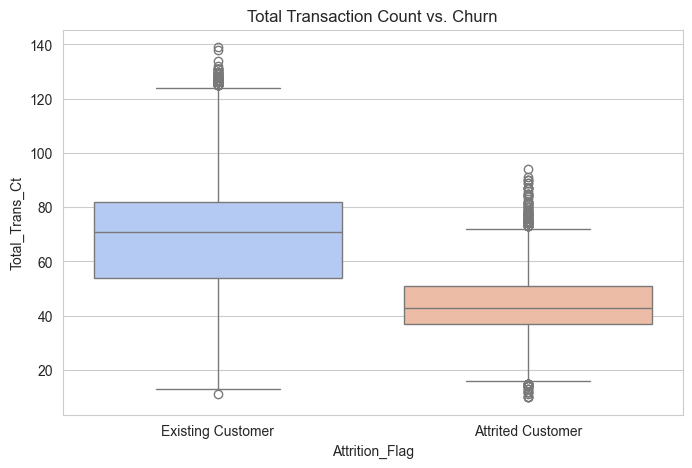

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Total_Trans_Ct", palette="coolwarm")
plt.title("Total Transaction Count vs. Churn")
plt.show()


5. Customer Engagement & Churn: <br>
-> To understand whether inactivity & customer service interactions impact churn.

5a. Inactivity vs. churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\2793712011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Months_Inactive_12_mon", palette="coolwarm")


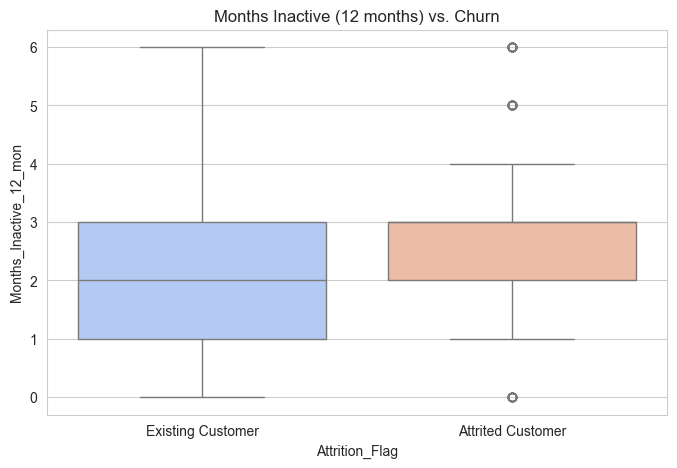

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Months_Inactive_12_mon", palette="coolwarm")
plt.title("Months Inactive (12 months) vs. Churn")
plt.show()


5b. Customer Support Calls vs. Churn

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\2146210943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Contacts_Count_12_mon", palette="coolwarm")


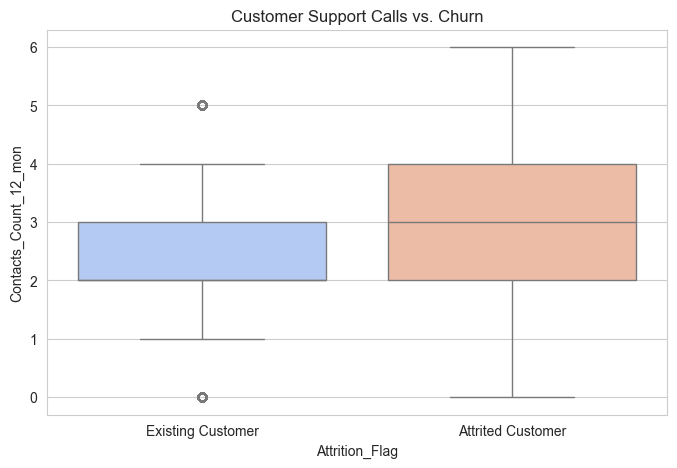

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x="Attrition_Flag", y="Contacts_Count_12_mon", palette="coolwarm")
plt.title("Customer Support Calls vs. Churn")
plt.show()


6. Correlation Analysis: <br>
-> To see how different numerical variables relate to churn.

C:\Users\bijin\AppData\Local\Temp\ipykernel_6284\63896516.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_cleaned.corr(), annot=True, cmap="coolwarm", fmt=".2f")


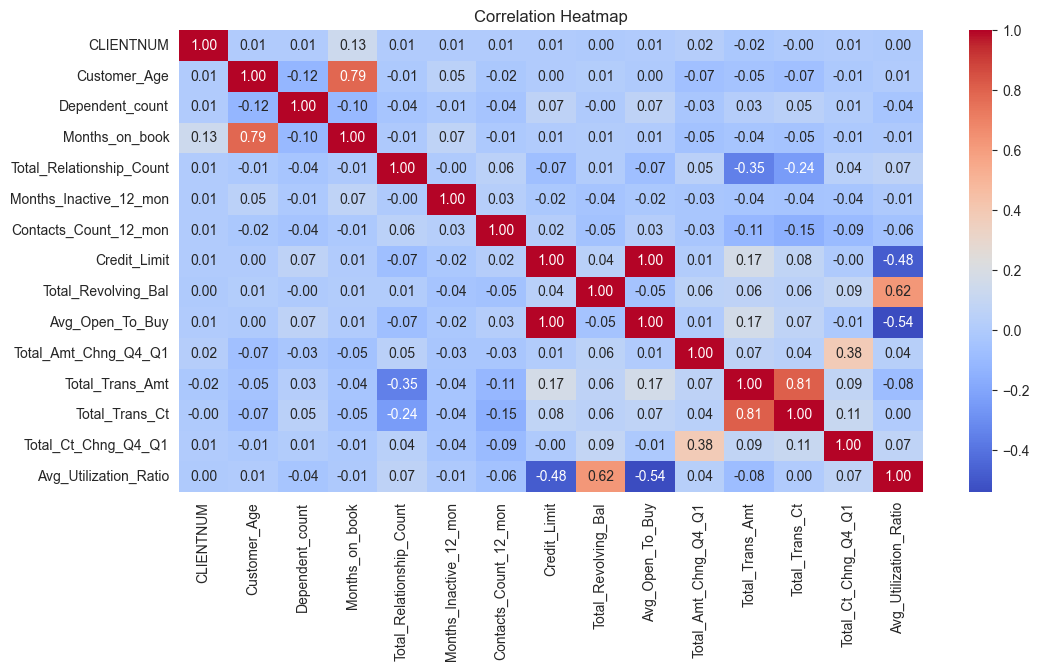

In [56]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Customer Behavior Analysis Findings

## 1. **Correlation Heatmap Analysis**
- **Strong Positive Correlations:**
  - `Customer_Age` & `Months_on_book` (**0.79**): Older customers tend to have longer account tenure.
  - `Total_Trans_Amt` & `Total_Trans_Ct` (**0.81**): More transactions correlate with higher spending.
  - `Total_Revolving_Bal` & `Avg_Utilization_Ratio` (**0.62**): Higher revolving balances indicate higher credit utilization.

- **Strong Negative Correlations:**
  - `Avg_Utilization_Ratio` & `Credit_Limit` (**-0.48**): Higher credit limits are associated with lower credit utilization.
  - `Total_Trans_Amt` & `Months_Inactive_12_mon` (**-0.35**): Customers with more inactive months tend to spend less.
  - `Avg_Utilization_Ratio` & `Avg_Open_To_Buy` (**-0.54**): Higher credit utilization means lower available credit.

## 2. **Customer Transactions & Activity Trends**
- Customers with **higher transaction counts** generally have higher total spending.
- **Inactive customers** (higher `Months_Inactive_12_mon`) show significantly lower transaction amounts.
- **Frequent customer service interactions** (`Contacts_Count_12_mon`) could indicate dissatisfaction or potential churn risk.

## 3. **Credit Utilization Behavior**
- Customers with **higher credit limits** tend to have **lower utilization ratios**, implying responsible credit management.
- High `Total_Revolving_Bal` suggests that some customers **carry significant outstanding balances**.

## 4. **Potential Churn Indicators**
- Customers with **higher inactive months** (`Months_Inactive_12_mon`) and **lower transaction amounts** are more likely to be disengaged.
- A **high number of customer service interactions** (`Contacts_Count_12_mon`) might indicate **customer frustration**.
- **Low transaction frequency** can be an early warning sign of customers **losing interest** in the services.

## 5. **Business Recommendations**
- **Increase Engagement:** Target customers with declining transactions using personalized offers and rewards.
- **Reduce Churn Risk:** Monitor inactivity trends and proactively reach out to high-risk customers.
- **Encourage Responsible Credit Use:** Offer better financial products to customers with good credit utilization patterns.
- **Leverage Transaction Data:** Use transaction frequency and amount as key indicators for segmenting high-value customers.

---

This analysis provides key insights into customer behavior, spending patterns, and potential churn indicators. Further predictive modeling can help in proactive customer retention strategies.

